In [ ]:
# AI attribution: written with the help of ChatGPT-5 and Gemini 2.5 Pro

In [1]:
!apt-get install tesseract-ocr -y
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [2]:
import cv2
import numpy as np
import pytesseract
from pytesseract import Output
import re

In [3]:
IMAGE_PATH = "/content/drive/MyDrive/floorplans/floorplan6.png"

img = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [4]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)
print("OCR image shape:", enhanced.shape)

OCR image shape: (1688, 2052)


In [5]:
tess_config = "--psm 12"   # adjust to 11/12 if text is more sparse
ocr_data1 = pytesseract.image_to_data(enhanced, output_type=Output.DICT, config=tess_config)

In [6]:
raw_words = []
for i in range(len(ocr_data1["text"])):
    txt = ocr_data1["text"][i].strip()
    conf_raw = ocr_data1["conf"][i]
    try:
        conf = int(conf_raw)
    except:
        conf = -1
    if conf > 20 and txt != "":
        raw_words.append((txt, conf))
print("Raw OCR words:", raw_words[:50])

Raw OCR words: [('B1016A', 47), ('B1016B', 84), ('B1016C', 91), ('B1014', 90), ('\\/', 88), ('4-person', 92), ('B1016', 91), ('4-person', 92), ('B1016D', 90), ('ZS', 58), ('>', 96), ('B1014B', 59), ('V7', 31), ('ZS)', 75), ('B1015', 67), ('4-person', 92), ('B1014C', 90), ('B1015A', 72), ('B1015B', 83), ('B1015C', 91), ('B1015D', 90), ('B1014D', 91), ('/\\', 66), ('ee', 28), ('a', 22), ('B1012', 91), ('4-person', 93), ('B1011A.', 54), ('cl', 56), ('———', 54), ('B1012A', 43), ('ZS)', 77), ('Lh', 48), ('B1011B', 80), ('“8', 21), ('B1012B', 92), ('B1011', 92), ('4-person', 81), ('B1012C', 91), ('Se', 21), ('a', 27), ('a', 23), ('ee', 26), ('ee', 43), ('ee', 47), ('a', 35), ('B1011C', 89), ('B1012D', 91), ('ZS)', 62), ('B1011D', 91)]


In [7]:
import re

# minimal settings you can tweak
PATTERN = re.compile(r'^[A-Z]\d{4}[A-Z]$', re.IGNORECASE)  # Letter-4digits-optionalLetter

def simple_filter(ocr_data):
    """
    ocr_data: result of pytesseract.image_to_data(..., output_type=Output.DICT)
    returns: list of dicts: {'text','conf','bbox','cx','cy'}
    """
    out = []
    n = len(ocr_data['text'])
    for i in range(n):
        raw = ocr_data['text'][i].strip()
        conf_raw = ocr_data['conf'][i] # Extract conf for current word
        try:
            conf = int(conf_raw)
        except:
            conf = -1

        # bbox
        try:
            x = int(ocr_data['left'][i]); y = int(ocr_data['top'][i])
            w = int(ocr_data['width'][i]); h = int(ocr_data['height'][i])
        except:
            continue
        # pattern match (case-insensitive) and confidence threshold
        if PATTERN.match(raw):
            cx = x + w/2.0; cy = y + h/2.0
            out.append({'text': raw, 'conf': conf, 'bbox': (x,y,w,h), 'cx': cx, 'cy': cy})
    return out

In [8]:
labels = simple_filter(ocr_data1)
print(f"Kept {len(labels)} labels:", [l['text'] for l in labels])

Kept 18 labels: ['B1016A', 'B1016B', 'B1016C', 'B1016D', 'B1014B', 'B1014C', 'B1015A', 'B1015B', 'B1015C', 'B1015D', 'B1014D', 'B1012A', 'B1011B', 'B1012B', 'B1012C', 'B1011C', 'B1012D', 'B1011D']


In [ ]:
vis = img.copy()
for lab in labels:
    x,y,w,h = lab['bbox']
    txt = lab['text']
    # green box, small circle at centroid
    cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 2)
    cv2.circle(vis, (int(lab['cx']), int(lab['cy'])), 4, (0,0,255), -1)
    cv2.putText(vis, txt, (x, max(0,y-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

# Save or show the visualization for QA
cv2.imwrite("ocr_debug_vis.png", vis)
print(f"Found {len(labels)} candidate labels. Debug image saved to ocr_debug_vis.png")


Found 18 candidate labels. Debug image saved to ocr_debug_vis.png


In [9]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 21.6 MB/s eta 0:00:00


In [10]:
import easyocr
reader = easyocr.Reader(['en'], gpu=False)
results2 = reader.readtext(enhanced, paragraph=False)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [11]:
easyocr_labels = []

for bbox, text, conf in results2:

    clean = text.strip().upper()

    # Require strict pattern (e.g., B1016A)
    if PATTERN.match(clean):
        # Convert bbox (4 corner points) to a simple rectangle
        xs = [int(p[0]) for p in bbox]
        ys = [int(p[1]) for p in bbox]

        x0, y0 = min(xs), min(ys)
        w, h = max(xs) - x0, max(ys) - y0

        cx = x0 + w/2
        cy = y0 + h/2

        easyocr_labels.append({
            'text': clean,
            'conf': conf,
            'bbox': (x0, y0, w, h),
            'cx': cx,
            'cy': cy
        })


# -------------------------------------------------------
# Print results
# -------------------------------------------------------
print(f"Found {len(easyocr_labels)} room labels:")
for L in easyocr_labels:
    print(f"{L['text']}  conf={L['conf']:.2f}  centroid=({L['cx']:.1f}, {L['cy']:.1f})  bbox={L['bbox']}")


# -------------------------------------------------------
# Optional: Draw boxes for debugging
# -------------------------------------------------------
vis = img.copy()

for L in easyocr_labels:
    x,y,w,h = L['bbox']
    cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(vis, L['text'], (x, y-8), cv2.FONT_HERSHEY_SIMPLEX,
                0.7, (0,255,0), 2)

cv2.imwrite("easyocr_debug.png", vis)
print("Debug image saved as easyocr_debug.png")


Found 11 room labels:
B1016A  conf=0.54  centroid=(503.0, 148.0)  bbox=(470, 136, 66, 24)
B1016B  conf=0.96  centroid=(655.0, 148.0)  bbox=(622, 136, 66, 24)
B1016C  conf=0.99  centroid=(799.0, 148.0)  bbox=(766, 136, 66, 24)
B1014A  conf=0.99  centroid=(1573.0, 299.0)  bbox=(1541, 289, 64, 20)
B1014B  conf=0.92  centroid=(1573.0, 451.0)  bbox=(1541, 441, 64, 20)
B1014C  conf=0.99  centroid=(1573.0, 602.0)  bbox=(1540, 590, 66, 24)
B1014D  conf=0.84  centroid=(1572.0, 747.0)  bbox=(1539, 737, 66, 20)
B1012A  conf=0.95  centroid=(1663.0, 1063.0)  bbox=(1631, 1053, 64, 20)
B1012B  conf=0.70  centroid=(1663.0, 1217.0)  bbox=(1631, 1207, 64, 20)
B1012C  conf=0.90  centroid=(1664.0, 1370.0)  bbox=(1630, 1358, 68, 24)
B1012D  conf=0.82  centroid=(1664.0, 1513.0)  bbox=(1631, 1503, 66, 20)
Debug image saved as easyocr_debug.png


combine the two results

In [12]:
import math

# helper: convert EasyOCR bbox (4 points) -> (x,y,w,h)
def easy_bbox_to_rect(bbox_points):
    xs = [int(p[0]) for p in bbox_points]
    ys = [int(p[1]) for p in bbox_points]
    x0, y0 = min(xs), min(ys)
    w, h = max(xs) - x0, max(ys) - y0
    return (x0, y0, w, h)

def iou_box(a, b):
    ax,ay,aw,ah = a; bx,by,bw,bh = b
    x1 = max(ax, bx); y1 = max(ay, by)
    x2 = min(ax+aw, bx+bw); y2 = min(ay+ah, by+bh)
    iw = max(0, x2-x1); ih = max(0, y2-y1)
    inter = iw * ih
    union = aw*ah + bw*bh - inter
    return inter/union if union>0 else 0.0

def centroid(box):
    x,y,w,h = box
    return (x + w/2.0, y + h/2.0)

def dist(p,q):
    return math.hypot(p[0]-q[0], p[1]-q[1])

def compliment_pytesseract_with_easyocr(tess_list, easy_list_dicts,
                                        iou_thresh=0.25, dist_thresh=30.0):
    """
    tess_list: list of dicts from pytesseract: {'text','conf','bbox':(x,y,w,h), 'cx','cy'}
    easy_list_dicts: list of dicts from EasyOCR (already filtered and formatted): {'text','conf','bbox':(x,y,w,h), 'cx','cy'}
    Returns: combined list (tess_list items first, then new easyocr items appended)
    """
    # build list of tess bboxes for quick comparison
    tess_boxes = [t['bbox'] for t in tess_list]
    tess_centroids = [ (t['cx'], t['cy']) for t in tess_list ]

    added = []
    for item in easy_list_dicts:
        text = item['text']
        conf_raw = item['conf'] # conf from easyocr_labels is 0-1
        rect = item['bbox']
        cx = item['cx']
        cy = item['cy']

        # check IoU against any tess box
        too_close = False
        for tb, tc in zip(tess_boxes, tess_centroids):
            if iou_box(tb, rect) >= iou_thresh:
                too_close = True
                break
            if dist((cx,cy), tc) <= dist_thresh:
                too_close = True
                break

        if not too_close:
            # normalize easyocr conf to 0..100 for parity
            try:
                conf100 = float(conf_raw) * 100.0 if float(conf_raw) <= 1.0 else float(conf_raw)
            except:
                conf100 = float(conf_raw) if isinstance(conf_raw, (int,float)) else -1.0

            added.append({
                'text': text,
                'conf': conf100,
                'bbox': rect,
                'cx': cx,
                'cy': cy,
                'source': 'easyocr'
            })

    # return combined (keep original tess entries first)
    combined = list(tess_list) + added
    return combined

In [13]:
combined = compliment_pytesseract_with_easyocr(labels, easyocr_labels,
                                              iou_thresh=0.25, dist_thresh=30.0)

print("original tess count:", len(labels))
print("easy-only added:", len(combined) - len(labels))
for item in combined:
    print(item['text'], item['conf'], item['bbox'], item.get('source','tesseract'))

original tess count: 18
easy-only added: 1
B1016A 47 (475, 142, 59, 13) tesseract
B1016B 84 (626, 142, 57, 13) tesseract
B1016C 91 (771, 142, 58, 13) tesseract
B1016D 90 (922, 226, 60, 13) tesseract
B1014B 59 (1545, 445, 57, 13) tesseract
B1014C 90 (1544, 597, 58, 13) tesseract
B1015A 72 (475, 608, 59, 13) tesseract
B1015B 83 (626, 608, 57, 13) tesseract
B1015C 91 (771, 608, 58, 13) tesseract
B1015D 90 (922, 608, 60, 13) tesseract
B1014D 91 (1543, 741, 60, 13) tesseract
B1012A 43 (1635, 1057, 59, 13) tesseract
B1011B 80 (1085, 1104, 57, 13) tesseract
B1012B 92 (1635, 1211, 58, 13) tesseract
B1012C 91 (1635, 1365, 58, 13) tesseract
B1011C 89 (1084, 1410, 58, 13) tesseract
B1012D 91 (1634, 1507, 60, 13) tesseract
B1011D 91 (1081, 1561, 59, 13) tesseract
B1014A 98.93185121456767 (1541, 289, 64, 20) easyocr


In [ ]:
vis_combined = img.copy()
for lab in combined:
    x,y,w,h = lab['bbox']
    txt = lab['text']
    # green box, small circle at centroid
    cv2.rectangle(vis_combined, (x,y), (x+w, y+h), (0,255,0), 2)
    cv2.circle(vis_combined, (int(lab['cx']), int(lab['cy'])), 4, (0,0,255), -1)
    cv2.putText(vis_combined, txt, (x, max(0,y-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

# Save or show the visualization for QA
cv2.imwrite("combined_debug_vis.png", vis_combined)
print(f"Found {len(combined)} combined labels. Debug image saved to combined_debug_vis.png")

Found 19 combined labels. Debug image saved to combined_debug_vis.png


combine masks with labels

In [16]:
import pickle
with open("filtered_masks.pkl", "rb") as f:
    filtered_masks = pickle.load(f)

print("Loaded", len(filtered_masks), "masks")

Loaded 17 masks


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont # Keep PIL import for image loading/saving, but not for drawing overlays
import random
import math
import matplotlib.patches as patches # Import for drawing rectangles

# --- Helper functions for visualization (moved here for self-containment) ---
def bbox_to_rect_int(bbox):
    x,y,w,h = bbox
    return int(round(x)), int(round(y)), int(round(w)), int(round(h))

def mask_bbox_from_bool(mask_bool):
    ys, xs = np.where(mask_bool)
    if ys.size == 0:
        return (0,0,0,0)
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    return (x0, y0, x1 - x0 + 1, y1 - y0 + 1)

# optional: try to import skimage for contours (nice outlines)
try:
    from skimage import measure
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False

def _random_color(seed=None):
    if seed is not None:
        random.seed(seed)
    # pastel-ish colors
    r = 100 + random.randint(0,155)
    g = 100 + random.randint(0,155)
    b = 100 + random.randint(0,155)
    return (r, g, b)

def _draw_mask_overlay(ax, mask, color, alpha=0.35, outline=True, linewidth=1.5):
    """
    mask: boolean HxW
    ax: matplotlib axis with image already shown
    """
    H, W = mask.shape
    # show filled mask via imshow with an RGBA image
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    r,g,b = [c/255.0 for c in color]
    rgba[...,0] = r
    rgba[...,1] = g
    rgba[...,2] = b
    rgba[...,3] = mask.astype(float) * alpha
    ax.imshow(rgba, interpolation='nearest')

    # outline via contours if available
    if outline and _HAS_SKIMAGE:
        contours = measure.find_contours(mask.astype(np.uint8), 0.5)
        for contour in contours:
            # contour is array of (row, col) -> plot as (x=col, y=row)
            xs = contour[:,1]; ys = contour[:,0]
            ax.plot(xs, ys, color=np.array(color)/255.0, linewidth=linewidth)

def _draw_bbox_and_text_mpl(ax, bbox, text, color=(255,255,255), text_color=(255,255,255), text_bg=(0,0,0,0.6)):
    """
    ax: matplotlib axis
    bbox: (x,y,w,h) - coordinates in image space
    text: string
    color: bbox outline color (RGB tuple, 0-255)
    text_color: text color (RGB tuple, 0-255)
    text_bg: tuple (R,G,B,A) for text background, where A is alpha (0-1)
    """
    x,y,w,h = bbox # bbox coordinates are already in image space
    # Rectangle
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor=np.array(color)/255.0, facecolor='none')
    ax.add_patch(rect)

    # Text background and text
    text_bg_mpl = (text_bg[0]/255.0, text_bg[1]/255.0, text_bg[2]/255.0, text_bg[3])
    text_color_mpl = np.array(text_color)/255.0

    # put text above the box if there is room, else inside top-left
    text_x = x
    text_y = max(0, y - 5) # 5 pixels above bbox

    ax.text(text_x, text_y, text,
            fontsize=8, # Adjust fontsize as needed
            color=text_color_mpl,
            bbox=dict(facecolor=text_bg_mpl[:3], alpha=text_bg_mpl[3], edgecolor='none', pad=1),
            verticalalignment='bottom', horizontalalignment='left'
           )

# Main visualization function
def visualize_matches_on_floorplan(image,
                                   matched_labels,
                                   unmatched_label_indices=None,
                                   unmatched_mask_indices=None,
                                   title="Floorplan: masks + labels",
                                   figsize=(12,8),
                                   save_path=None,
                                   show=True):
    """
    image: HxW x3 array (uint8) or PIL Image or path-to-image
    matched_labels: list of label dicts after matching. Each item should have:
        - 'bbox': (x,y,w,h)
        - 'text'
        - 'mask': boolean array or None
        - 'mask_id': int or None
        - 'mask_iou' optionally
    unmatched_label_indices: list of label indices considered unmatched (optional)
    unmatched_mask_indices: list of mask indices considered unmatched (optional)
    """
    # normalize image to numpy array
    if isinstance(image, str):
        img_pil = Image.open(image).convert("RGB")
        arr = np.array(img_pil)
    elif isinstance(image, Image.Image):
        arr = np.array(image.convert("RGB"))
    else:
        arr = np.asarray(image).astype(np.uint8)
        if arr.ndim == 2:
            arr = np.stack([arr]*3, axis=-1)
        if arr.shape[2] == 4:
            arr = arr[...,:3]

    H_img, W_img = arr.shape[:2]

    # Create matplotlib figure and axes
    # Adjust figsize dynamically to match image dimensions for accurate drawing when saving
    if save_path:
        dpi = 100 # A common dpi
        figsize = (W_img / dpi, H_img / dpi)
        fig, ax = plt.subplots(1,1, figsize=figsize, dpi=dpi)
    else:
        fig, ax = plt.subplots(1,1, figsize=figsize)

    ax.imshow(arr)
    ax.axis('off')
    ax.set_title(title)
    fig.tight_layout(pad=0) # Remove padding to ensure image fills figure if dpi is matching

    # generate colors for each unique mask_id (including None)
    mask_ids = sorted({item.get('mask_id') for item in matched_labels if item.get('mask_id') is not None})
    color_map = {}
    for mid in mask_ids:
        color_map[mid] = _random_color(seed=mid)

    # overlay masks (matched ones)
    for li, lab in enumerate(matched_labels):
        mid = lab.get('mask_id')
        mask = lab.get('mask')
        if mask is None or mid is None:
            continue
        color = color_map.get(mid, _random_color(seed=mid))
        # If mask shape doesn't match image, try to warn and skip
        if mask.shape[0] != H_img or mask.shape[1] != W_img:
            print(f"[warning] mask_id {mid} shape {mask.shape} != image shape {(H_img,W_img)}; skipping overlay")
            continue
        _draw_mask_overlay(ax, mask, color=color, alpha=0.25, outline=True)

    # draw bboxes and texts (labels) - using the new matplotlib function
    for li, lab in enumerate(matched_labels):
        bbox = lab.get('bbox')
        text = lab.get('text', '')
        mid = lab.get('mask_id')
        iou = lab.get('mask_iou', None)
        # annotate text with mask id + iou if present
        txt = text
        if mid is not None:
            txt = f"{text} (m{mid}"
            if iou is not None:
                txt += f", iou={iou:.2f}"
            txt += ")"
        # color based on matched/unmatched
        if unmatched_label_indices and li in unmatched_label_indices:
            box_color = (255, 0, 0)  # red for unmatched label
            text_bg = (200, 30, 30, 200/255.0) # Normalized alpha
        else:
            if mid is None:
                box_color = (255, 165, 0)  # orange for label with no matched mask
                text_bg = (180,120,30,200/255.0) # Normalized alpha
            else:
                box_color = color_map.get(mid, (100,200,100)) # Use mask color for box if matched
                text_bg = (0,0,0,160/255.0) # Normalized alpha
        # draw using matplotlib function
        _draw_bbox_and_text_mpl(ax, bbox, txt, color=box_color, text_color=(255,255,255), text_bg=text_bg)

    # Optionally mark unmatched masks (outline them in red dashed)
    if unmatched_mask_indices:
        for mid in unmatched_mask_indices:
            mask_found = None
            # Attempt to find the mask in any matched_labels (even if its label wasn't matched)
            # A more robust solution might require passing the original filtered_masks to this function
            for lab in matched_labels:
                if lab.get('mask_id') == mid and lab.get('mask') is not None:
                    mask_found = lab.get('mask')
                    break
            # Fallback: if not found through matched_labels, it means an original SAM mask was unmatched
            # We'd need access to `filtered_masks` here to draw its outline. For now, skip.
            if mask_found is None: # This means the mask wasn't associated with any label in matched_labels
                continue # Cannot draw it without the mask data

            if _HAS_SKIMAGE:
                contours = measure.find_contours(mask_found.astype(np.uint8), 0.5)
                for contour in contours:
                    # contour is array of (row, col) -> plot as (x=col, y=row)
                    ax.plot(contour[:,1], contour[:,0], color='red', linestyle='--', linewidth=2)
            else:
                bx = mask_bbox_from_bool(mask_found)
                x,y,w,h = bx
                rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', linestyle='--', facecolor='none')
                ax.add_patch(rect)

    # If saving, use fig.savefig directly for matplotlib output
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', pad_inches=0)
        print("Saved visualization to", save_path)

    if show:
        plt.show()
    plt.close(fig) # Close the figure to free up memory

    # Return a rendered PIL Image and numpy array for consistency if needed.
    # If save_path is provided, load from there. Otherwise, render to buffer.
    if save_path:
        pil_img = Image.open(save_path).convert("RGB")
        out_arr = np.array(pil_img)
    else:
        fig_temp, ax_temp = plt.subplots(figsize=(W_img/100, H_img/100), dpi=100)
        ax_temp.imshow(arr) # Render original image to get basic canvas size
        ax_temp.axis('off'); fig_temp.tight_layout(pad=0)
        fig_temp.canvas.draw()
        buf = fig_temp.canvas.buffer_rgba()
        w, h = fig_temp.canvas.get_width_height()
        pil_img = Image.frombuffer("RGBA", (w, h), buf, "raw", "RGBA", 0, 1).convert("RGB")
        out_arr = np.array(pil_img)
        plt.close(fig_temp)

    return pil_img, out_arr

In [19]:
import numpy as np
import math

def centroid_inside_mask(mask_bool, cx, cy):
    """
    Return True if centroid (cx,cy) lies within mask_bool.
    mask_bool is HxW, cx/cy are float coords in image pixel space.
    """
    if mask_bool is None:
        return False
    H, W = mask_bool.shape
    xi = int(round(cx)); yi = int(round(cy))
    if xi < 0 or yi < 0 or xi >= W or yi >= H:
        return False
    return bool(mask_bool[yi, xi])

def one_to_one_match_by_centroid(combined_labels, sam_masks):
    """
    One-to-one matcher that assigns a mask to a label if and only if the label centroid
    is inside the mask. Enforces one-to-one: if multiple labels are inside the same mask,
    keep the label with highest label['conf'] (fall back to label order).
    Parameters:
      - combined_labels: list of label dicts. Each must have 'cx','cy','bbox','text','conf' (conf optional)
      - sam_masks: list of mask dicts. Each must contain a boolean array at key 'segmentation'
    Returns:
      - matched_labels: shallow copies of combined_labels augmented with:
           'mask' (bool ndarray or None),
           'mask_id' (int or None),
           'mask_iou' (0.0)  # IoU not computed here
      - unmatched_label_indices: list of indices in combined_labels not matched
      - unmatched_mask_indices: list of indices in sam_masks not matched
    """
    nL = len(combined_labels)
    nM = len(sam_masks)

    # Build boolean masks array list, ensure dtype bool
    bool_masks = []
    for mi, m in enumerate(sam_masks):
        if isinstance(m, dict) and 'segmentation' in m:
            seg = np.asarray(m['segmentation']).astype(bool)
            bool_masks.append(seg)
        elif isinstance(m, dict) and 'mask' in m:  # fallback key
            seg = np.asarray(m['mask']).astype(bool)
            bool_masks.append(seg)
        else:
            raise ValueError(f"sam_masks[{mi}] missing 'segmentation' or 'mask' key")

    # For each mask, collect candidate labels whose centroid falls inside it
    mask_candidates = {mi: [] for mi in range(nM)}
    label_candidates = {li: [] for li in range(nL)}  # optional reverse mapping

    for li, lab in enumerate(combined_labels):
        cx = lab.get('cx')
        cy = lab.get('cy')
        if cx is None or cy is None:
            # try to compute from bbox if cx/cy absent
            bx, by, bw, bh = lab.get('bbox', (0,0,0,0))
            cx = bx + bw/2.0
            cy = by + bh/2.0
        for mi, mask_bool in enumerate(bool_masks):
            if centroid_inside_mask(mask_bool, cx, cy):
                mask_candidates[mi].append(li)
                label_candidates[li].append(mi)

    # Greedy one-to-one: for each mask, pick the best label (highest conf). If tie use label index order.
    label_assigned = [-1] * nL
    mask_assigned = [-1] * nM

    for mi in range(nM):
        cands = mask_candidates.get(mi, [])
        if not cands:
            continue
        # choose best candidate by conf (higher better). handle missing conf
        def conf_of(li):
            conf = combined_labels[li].get('conf', None)
            try:
                # try to convert string confs to float
                return float(conf) if conf is not None else -1.0
            except:
                return -1.0
        best_li = max(cands, key=lambda li: (conf_of(li), -li))  # prefer higher conf, tie-break lower index
        # assign if that label is not already assigned to another mask
        if label_assigned[best_li] == -1:
            label_assigned[best_li] = mi
            mask_assigned[mi] = best_li
        else:
            # If the chosen label is already assigned to another mask, we can compare confs and reassign.
            prev_m = label_assigned[best_li]
            # prefer the mask that appears earlier (stable) — simplest deterministic behavior
            # (you can implement fancy swapping if desired)
            # We'll keep first assignment and skip reassignments.
            continue

    # Build output matched_labels with augmentation
    matched_labels = []
    for li, lab in enumerate(combined_labels):
        labc = dict(lab)  # shallow copy
        mid = label_assigned[li]
        if mid != -1:
            labc['mask'] = bool_masks[mid]
            labc['mask_id'] = int(mid)
            labc['mask_iou'] = 0.0
        else:
            labc['mask'] = None
            labc['mask_id'] = None
            labc['mask_iou'] = 0.0
        matched_labels.append(labc)

    unmatched_label_indices = [i for i, a in enumerate(label_assigned) if a == -1]
    unmatched_mask_indices = [i for i, a in enumerate(mask_assigned) if a == -1]

    return matched_labels, unmatched_label_indices, unmatched_mask_indices


In [20]:
matched_labels_centroid, unmatched_labels_centroid, unmatched_masks_centroid = one_to_one_match_by_centroid(combined, filtered_masks)

print("Matched count:", sum(1 for x in matched_labels_centroid if x['mask'] is not None))
print("Unmatched labels:", unmatched_labels_centroid)
print("Unmatched masks:", unmatched_masks_centroid)

# quick per-match print
for i, lab in enumerate(matched_labels_centroid):
    print(i, lab['text'], "mask_id=", lab['mask_id'], "centroid=(", lab.get('cx'), lab.get('cy'), ")")


Matched count: 16
Unmatched labels: [13, 16, 17]
Unmatched masks: [10]
0 B1016A mask_id= 2 centroid=( 504.5 148.5 )
1 B1016B mask_id= 0 centroid=( 654.5 148.5 )
2 B1016C mask_id= 1 centroid=( 800.0 148.5 )
3 B1016D mask_id= 3 centroid=( 952.0 232.5 )
4 B1014B mask_id= 11 centroid=( 1573.5 451.5 )
5 B1014C mask_id= 12 centroid=( 1573.0 603.5 )
6 B1015A mask_id= 7 centroid=( 504.5 614.5 )
7 B1015B mask_id= 4 centroid=( 654.5 614.5 )
8 B1015C mask_id= 5 centroid=( 800.0 614.5 )
9 B1015D mask_id= 6 centroid=( 952.0 614.5 )
10 B1014D mask_id= 15 centroid=( 1573.0 747.5 )
11 B1012A mask_id= 13 centroid=( 1664.5 1063.5 )
12 B1011B mask_id= 8 centroid=( 1113.5 1110.5 )
13 B1012B mask_id= None centroid=( 1664.0 1217.5 )
14 B1012C mask_id= 16 centroid=( 1664.0 1371.5 )
15 B1011C mask_id= 9 centroid=( 1113.0 1416.5 )
16 B1012D mask_id= None centroid=( 1664.0 1513.5 )
17 B1011D mask_id= None centroid=( 1110.5 1567.5 )
18 B1014A mask_id= 14 centroid=( 1573.0 299.0 )


In [21]:
unmatched_bboxes = []
for idx in unmatched_labels_centroid:
    label = combined[idx]
    unmatched_bboxes.append(label['bbox'])

print(f"Bounding boxes of {len(unmatched_bboxes)} unmatched labels:")
for bbox in unmatched_bboxes:
    print(bbox)

# You can now use 'unmatched_bboxes' as input prompts for SAM

Bounding boxes of 3 unmatched labels:
(1635, 1211, 58, 13)
(1634, 1507, 60, 13)
(1081, 1561, 59, 13)


Saved visualization to viz_floorplan_matches.png


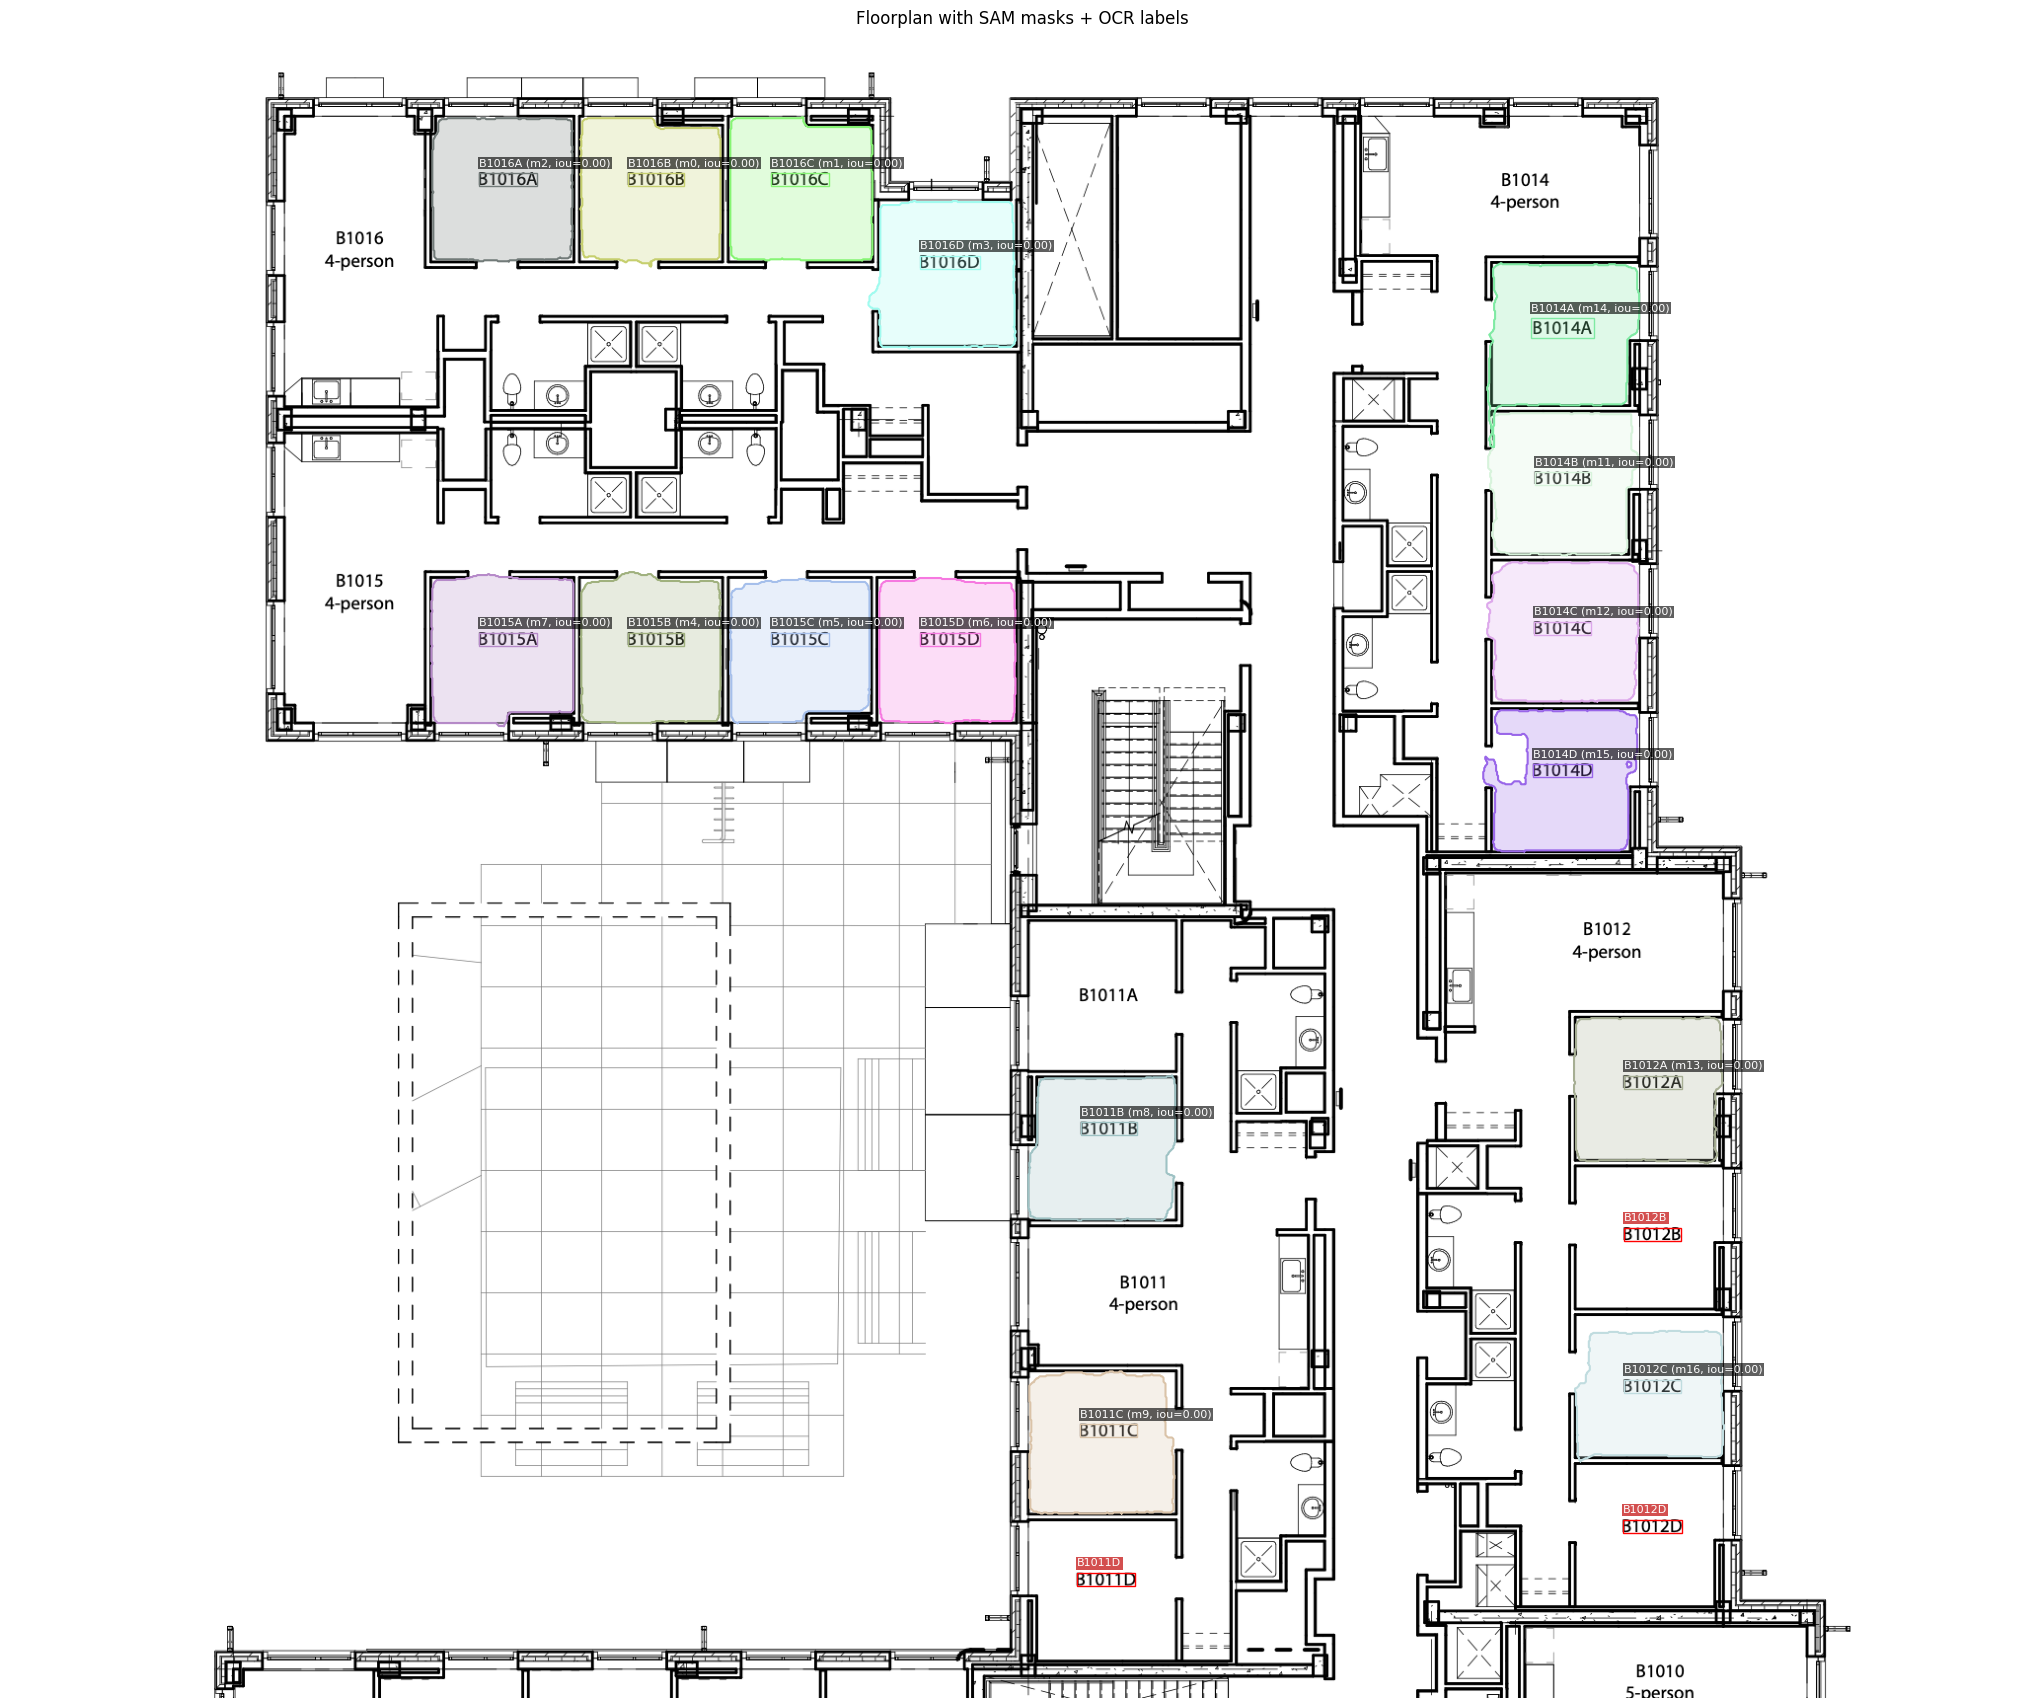

In [33]:
img_path = "/content/drive/MyDrive/floorplans/floorplan6.png"   # or your numpy image
out_img, out_arr = visualize_matches_on_floorplan(img_path,
                                                  matched_labels_centroid,
                                                  unmatched_label_indices=unmatched_labels_centroid,
                                                  unmatched_mask_indices=unmatched_masks_centroid,
                                                  title="Floorplan with SAM masks + OCR labels",
                                                  save_path="viz_floorplan_matches.png",
                                                  show=True)

In [24]:
with open("masks.pkl", "rb") as f:
    additional_masks = pickle.load(f)

print("Loaded", len(additional_masks), "additional masks")

Loaded 3 additional masks


In [25]:
# masks has shape (N, H, W)
N = additional_masks.shape[0]

new_mask_dicts = []

for i in range(additional_masks.shape[0]):
    seg = np.squeeze(additional_masks[i]).astype(bool)

    # area
    area = int(seg.sum())

    # bbox
    ys, xs = np.where(seg)
    if len(xs) == 0:
        continue  # skip empty mask

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    bbox = [int(x_min), int(y_min), int(x_max - x_min), int(y_max - y_min)]

    # predicted iou from predictor
    iou = 1.0

    # point coords (you already used these for prompting)
    pc = None

    # stability score: predictor does not return this, so put 1.0 or compute later
    stability = 1.0

    # crop_box: SAM2AutoMaskGenerator uses format [x0, y0, w, h]
    # If you predicted on the whole image, use:
    crop_box = [0, 0, seg.shape[1], seg.shape[0]]

    new_mask_dicts.append({
        "segmentation": seg,
        "area": area,
        "bbox": bbox,
        "predicted_iou": iou,
        "point_coords": pc,
        "stability_score": stability,
        "crop_box": crop_box,
    })


In [26]:
filtered_masks.extend(new_mask_dicts)
print(filtered_masks[17])

{'segmentation': array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]]), 'area': 21456, 'bbox': [1573, 1152, 177, 142], 'predicted_iou': 1.0, 'point_coords': None, 'stability_score': 1.0, 'crop_box': [0, 0, 2052, 1688]}


In [29]:
def create_rectangular_mask(mask_bool):
    """
    Creates a new boolean mask representing the tightest axis-aligned bounding box
    of the input irregular mask.

    Args:
        mask_bool (np.ndarray): A 2D boolean NumPy array representing an irregular mask.

    Returns:
        np.ndarray: A new 2D boolean NumPy array representing the rectangular bounding box.
    """
    H, W = mask_bool.shape

    # Use the existing mask_bbox_from_bool to get the bounding box
    x, y, w, h = mask_bbox_from_bool(mask_bool)

    # Create a new boolean array of the same dimensions, initialized to False
    rectangular_mask = np.full((H, W), False, dtype=bool)

    # Fill the rectangular region with True values
    # Ensure coordinates are within bounds
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(W, x + w)
    y2 = min(H, y + h)

    if x2 > x1 and y2 > y1:
        rectangular_mask[y1:y2, x1:x2] = True

    return rectangular_mask

print("Defined function: create_rectangular_mask")

Defined function: create_rectangular_mask


In [30]:
for mask_dict in filtered_masks:
    # 2. For each mask dictionary, retrieve the boolean array stored under the 'segmentation' key.
    original_segmentation = mask_dict['segmentation']

    # 3. Call the create_rectangular_mask function, passing the retrieved 'segmentation' boolean array as an argument.
    rectangular_segmentation = create_rectangular_mask(original_segmentation)

    # 4. Update the 'segmentation' key in the current mask dictionary with this new rectangular boolean array.
    mask_dict['segmentation'] = rectangular_segmentation

    # 5. Re-calculate the 'area' of the mask by summing the True values in the new rectangular 'segmentation' and update the 'area' key in the mask dictionary.
    mask_dict['area'] = int(rectangular_segmentation.sum())

    # 6. Re-calculate the 'bbox' (x, y, w, h) of the mask using the mask_bbox_from_bool function on the new rectangular 'segmentation' and update the 'bbox' key in the mask dictionary.
    mask_dict['bbox'] = mask_bbox_from_bool(rectangular_segmentation)

print("Filtered masks updated with rectangular approximations.")
# Example of one updated mask
print("First updated mask example:", filtered_masks[0])

Filtered masks updated with rectangular approximations.
First updated mask example: {'segmentation': array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]]), 'area': 21300, 'bbox': (578, 87, 142, 150), 'predicted_iou': 0.97265625, 'point_coords': [[595.40625, 123.8125]], 'stability_score': 0.9538044929504395, 'crop_box': [0.0, 0.0, 1314.0, 1132.0]}


In [35]:
matched_labels_centroid2, unmatched_labels_centroid2, unmatched_masks_centroid2 = one_to_one_match_by_centroid(combined, filtered_masks)

print("Matched count:", sum(1 for x in matched_labels_centroid2 if x['mask'] is not None))
print("Unmatched labels:", unmatched_labels_centroid2)
print("Unmatched masks:", unmatched_masks_centroid2)

# quick per-match print
for i, lab in enumerate(matched_labels_centroid2):
    print(i, lab['text'], "mask_id=", lab['mask_id'], "centroid=(", lab.get('cx'), lab.get('cy'), ")")

Matched count: 19
Unmatched labels: []
Unmatched masks: [10]
0 B1016A mask_id= 2 centroid=( 504.5 148.5 )
1 B1016B mask_id= 0 centroid=( 654.5 148.5 )
2 B1016C mask_id= 1 centroid=( 800.0 148.5 )
3 B1016D mask_id= 3 centroid=( 952.0 232.5 )
4 B1014B mask_id= 11 centroid=( 1573.5 451.5 )
5 B1014C mask_id= 12 centroid=( 1573.0 603.5 )
6 B1015A mask_id= 7 centroid=( 504.5 614.5 )
7 B1015B mask_id= 4 centroid=( 654.5 614.5 )
8 B1015C mask_id= 5 centroid=( 800.0 614.5 )
9 B1015D mask_id= 6 centroid=( 952.0 614.5 )
10 B1014D mask_id= 15 centroid=( 1573.0 747.5 )
11 B1012A mask_id= 13 centroid=( 1664.5 1063.5 )
12 B1011B mask_id= 8 centroid=( 1113.5 1110.5 )
13 B1012B mask_id= 17 centroid=( 1664.0 1217.5 )
14 B1012C mask_id= 16 centroid=( 1664.0 1371.5 )
15 B1011C mask_id= 9 centroid=( 1113.0 1416.5 )
16 B1012D mask_id= 18 centroid=( 1664.0 1513.5 )
17 B1011D mask_id= 19 centroid=( 1110.5 1567.5 )
18 B1014A mask_id= 14 centroid=( 1573.0 299.0 )


Saved visualization to viz_floorplan_matches.png


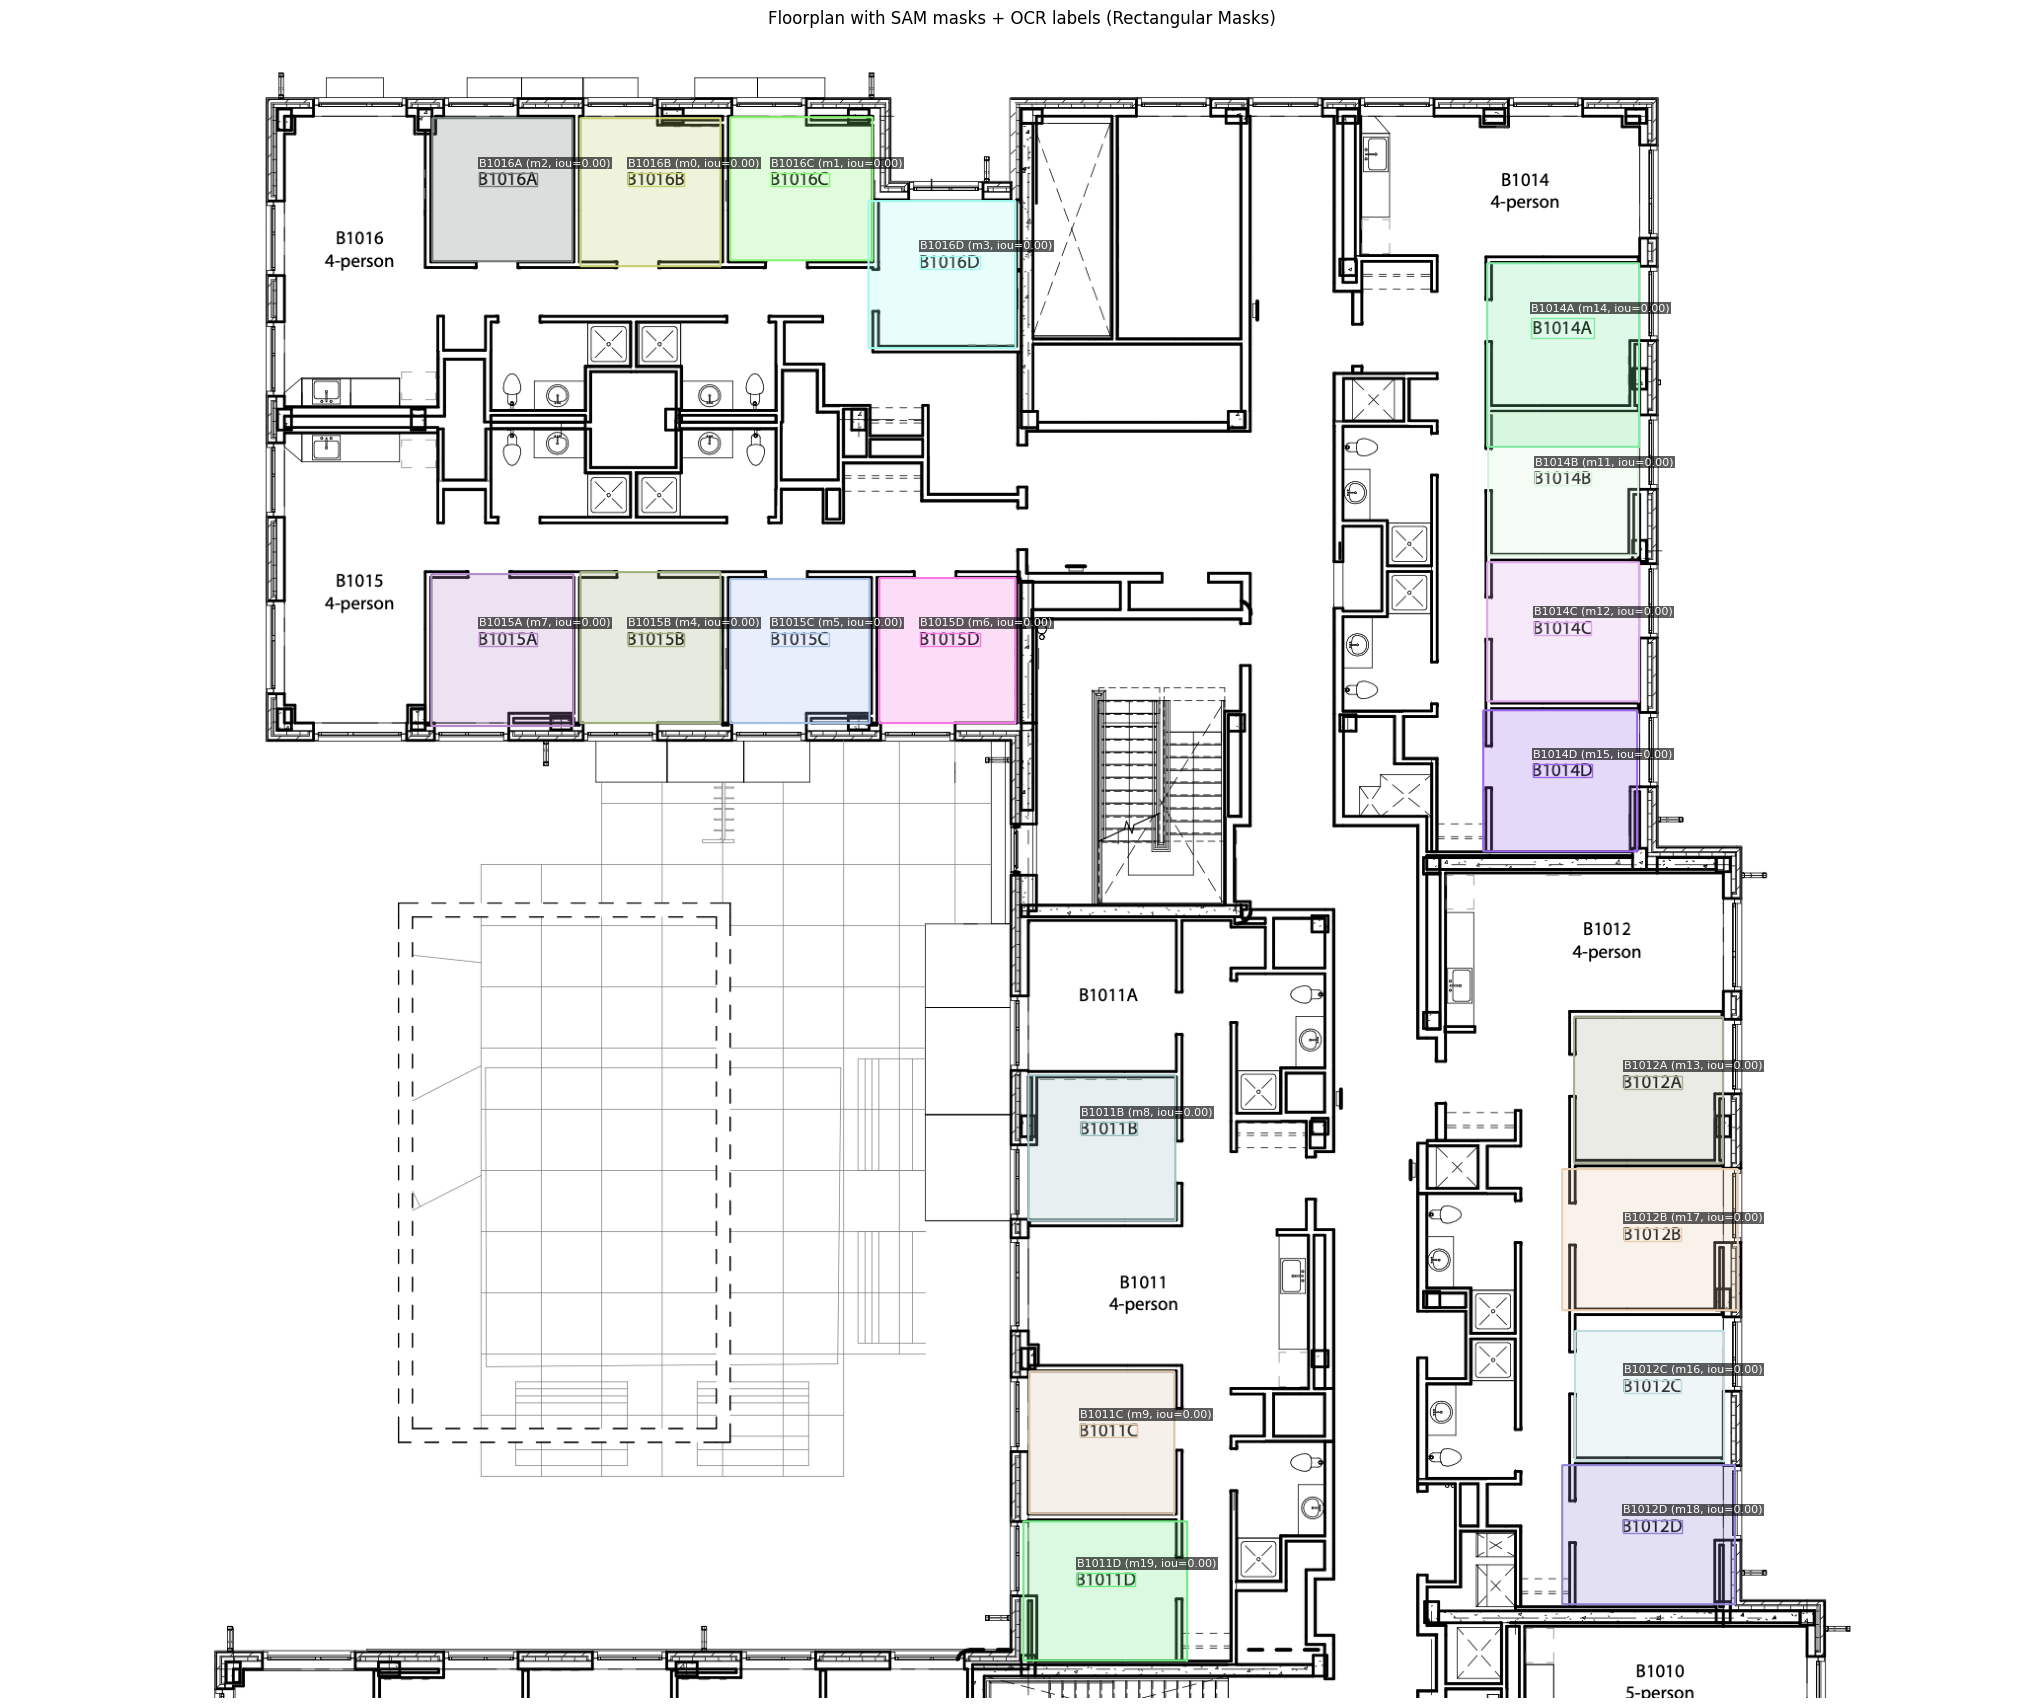

In [36]:
out_img, out_arr = visualize_matches_on_floorplan(img_path,
                                                  matched_labels_centroid2,
                                                  unmatched_label_indices=unmatched_labels_centroid2,
                                                  unmatched_mask_indices=unmatched_masks_centroid2,
                                                  title="Floorplan with SAM masks + OCR labels (Rectangular Masks)",
                                                  save_path="viz_floorplan_matches.png",
                                                  show=True)

In [38]:
# save_masks_and_labels.py
import os
import json
# Replace with your matched labels list variable name:
matched_labels = matched_labels_centroid2  # from your code

out_dir = "/content/floorplan_data"   # change as you prefer
os.makedirs(out_dir, exist_ok=True)

labels_out = []
for i, lab in enumerate(matched_labels):
    mask = lab.get('mask')  # expected to be a boolean ndarray or None
    text = lab.get('text', f'label_{i}')
    mask_id = lab.get('mask_id')

    # Save mask if present
    if mask is not None:
        # ensure numpy array and boolean
        arr = np.asarray(mask).astype(bool)
        # convert to uint8 0/255
        png = (arr.astype(np.uint8) * 255)
        im = Image.fromarray(png)
        mask_filename = f"mask_{i}.png"
        im.save(os.path.join(out_dir, mask_filename))
    else:
        mask_filename = None

    labels_out.append({
        "index": i,
        "text": text,
        "mask_id": mask_id,
        "mask_file": mask_filename
    })

# Save labels manifest (JSON)
with open(os.path.join(out_dir, "labels.json"), "w", encoding="utf-8") as f:
    json.dump({
        "base_image": "floorplan6.png",  # change if your base image name differs
        "labels": labels_out
    }, f, indent=2)

print("Wrote masks and labels manifest to", out_dir)


Wrote masks and labels manifest to /content/floorplan_data
